In [ ]:
!pip install timm -q

import torch
import torch.nn as nn
import torch.optim as optim
import timm
import pandas as pd
import numpy as np
import json
import os
import random
from PIL import Image, ImageEnhance
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    confusion_matrix, roc_auc_score,
    f1_score, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

BASE          = '/content/drive/MyDrive/CDT_Dataset'
HUMAN_FOLDER  = f'{BASE}/images_human_fixed'
AUG_FOLDER    = f'{BASE}/images_human_aug'
RESULT_FOLDER = f'{BASE}/results'
MODEL_FOLDER  = f'{BASE}/models_binary'

os.makedirs(MODEL_FOLDER,  exist_ok=True)
os.makedirs(RESULT_FOLDER, exist_ok=True)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
CUTOFF = 6
print(f'Device: {device}')

Mounted at /content/drive
Device: cuda


In [ ]:
def to_binary(df):
    """
    แปลง 3-class label เป็น binary
    A, C, D, E: 0,1 → 0 | 2 → 1
    B         : 0   → 0 | 1,2 → 1
    """
    df = df.copy()

    # A, C, D, E: poor=(0,1) good=(2)
    for col in ['domain_A', 'domain_C',
                'domain_D', 'domain_E']:
        df[col] = (df[col] == 2).astype(int)

    # B: poor=(0) good=(1,2)
    df['domain_B'] = (df['domain_B'] >= 1).astype(int)

    df['total_score']   = (
        df['domain_A'] + df['domain_B'] +
        df['domain_C'] + df['domain_D'] +
        df['domain_E']
    )
    df['dementia_risk'] = df['total_score'] < 3

    return df

train_df = pd.read_csv(
    f'{BASE}/labels/human_train.csv'
)
val_df   = pd.read_csv(
    f'{BASE}/labels/human_val.csv'
)
test_df  = pd.read_csv(
    f'{BASE}/labels/human_test.csv'
)

train_bin = to_binary(train_df)
val_bin   = to_binary(val_df)
test_bin  = to_binary(test_df)

print('Distribution หลัง Binary Label:')
print(f'{"Domain":<25} {"Class 0":>10} {"Class 1":>10}')
print('='*48)

for col, name in [
    ('domain_A', 'A: digit_count'),
    ('domain_B', 'B: worst_quadrant'),
    ('domain_C', 'C: spatial'),
    ('domain_D', 'D: hands_present'),
    ('domain_E', 'E: hands_placement'),
]:
    c0 = (train_bin[col] == 0).sum()
    c1 = (train_bin[col] == 1).sum()
    print(f'{name:<25} {c0:>10} {c1:>10}')

print('='*48)
print(f'\nDementia risk:')
print(f'  Normal  : {(~train_bin["dementia_risk"]).sum()}')
print(f'  Dementia: {train_bin["dementia_risk"].sum()}')

for split, df in [
    ('train', train_bin),
    ('val',   val_bin),
    ('test',  test_bin),
]:
    df.to_csv(
        f'{BASE}/labels/human_{split}_binary.csv',
        index=False
    )

Distribution หลัง Binary Label:
Domain                       Class 0    Class 1
A: digit_count                   599       4022
B: worst_quadrant                707       3914
C: spatial                       882       3739
D: hands_present                2155       2466
E: hands_placement              1310       3311

Dementia risk:
  Normal  : 3848
  Dementia: 773


In [ ]:
class CDTBinaryDataset(Dataset):
    def __init__(self, df, image_folder,
                 aug_folder=None, transform=None):
        self.df           = df.reset_index(drop=True)
        self.image_folder = image_folder
        self.aug_folder   = aug_folder
        self.transform    = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        filename = row['filename']

        if (self.aug_folder and
                filename.startswith('aug')):
            img_path = f'{self.aug_folder}/{filename}'
        else:
            img_path = f'{self.image_folder}/{filename}'

        try:
            img = Image.open(img_path).convert('RGB')
        except:
            img = Image.new('RGB', (224,224),
                           (255,255,255))

        if self.transform:
            img = self.transform(img)

        labels = torch.tensor([
            row['domain_A'], row['domain_B'],
            row['domain_C'], row['domain_D'],
            row['domain_E']
        ], dtype=torch.float32)

        return img, labels

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

In [ ]:
class CDTBinaryModel(nn.Module):
    """
    ต่างจาก CDTModel ตรงที่
    heads_cls output = 2 class (แทน 3)
    heads_reg output = 1 (0-1 แทน 0-2)
    """
    def __init__(self, backbone_name='vit',
                 num_domains=5):
        super().__init__()

        if backbone_name == 'vit':
            self.backbone = timm.create_model(
                'vit_base_patch16_224',
                pretrained=True,
                num_classes=0
            )
            self.feature_dim = 768
        else:
            backbone = models.resnet50(
                weights=models.ResNet50_Weights.IMAGENET1K_V1
            )
            self.feature_dim = 2048
            self.backbone = nn.Sequential(
                *list(backbone.children())[:-1]
            )

        self.backbone_name = backbone_name

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.heads_cls = nn.ModuleList([
            nn.Linear(512, 2)
            for _ in range(num_domains)
        ])

        self.heads_reg = nn.ModuleList([
            nn.Linear(512, 1)
            for _ in range(num_domains)
        ])

    def forward(self, x, mode='cls'):
        if self.backbone_name == 'vit':
            feat = self.backbone(x)
            feat = feat.unsqueeze(-1).unsqueeze(-1)
        else:
            feat = self.backbone(x)

        feat = self.shared(feat)

        if mode == 'reg':
            return [
                torch.sigmoid(head(feat).squeeze(-1))
                for head in self.heads_reg
            ]
        else:
            return [head(feat)
                    for head in self.heads_cls]

test_m = CDTBinaryModel('vit').to(device)
dummy  = torch.randn(2, 3, 224, 224).to(device)
out    = test_m(dummy, mode='cls')
print(f'CLS output: {[o.shape for o in out]}')
out2   = test_m(dummy, mode='reg')
print(f'REG output: {[o.shape for o in out2]}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

CLS output: [torch.Size([2, 2]), torch.Size([2, 2]), torch.Size([2, 2]), torch.Size([2, 2]), torch.Size([2, 2])]
REG output: [torch.Size([2]), torch.Size([2]), torch.Size([2]), torch.Size([2]), torch.Size([2])]


In [ ]:
def compute_binary_loss_weighted(
    outputs, labels, mode='cls'
):
    total = 0
    class_weights = {
        'A': torch.tensor([6.7, 1.0]).to(device),
        'B': torch.tensor([5.5, 1.0]).to(device),
        'C': torch.tensor([4.2, 1.0]).to(device),
        'D': torch.tensor([1.1, 1.0]).to(device),
        'E': torch.tensor([2.5, 1.0]).to(device),
    }
    domains = ['A', 'B', 'C', 'D', 'E']

    for i, output in enumerate(outputs):
        d = domains[i]
        if mode == 'reg':
            pos_weight = class_weights[d][0]
            loss = nn.BCEWithLogitsLoss(
                pos_weight=torch.tensor(
                    1.0/pos_weight
                ).to(device)
            )(output, labels[:, i].float())
        else:
            loss = nn.CrossEntropyLoss(
                weight=class_weights[d]
            )(output, labels[:, i].long())

        total += loss * DOMAIN_WEIGHTS[i]
    return total / DOMAIN_WEIGHTS.sum()

In [ ]:
DOMAIN_WEIGHTS = torch.tensor(
    [1.0, 1.5, 1.0, 1.0, 1.0]
).to(device)

def compute_binary_loss(outputs, labels, mode='cls'):
    total = 0
    for i, output in enumerate(outputs):
        if mode == 'reg':
            loss = nn.BCELoss()(
                output, labels[:, i].float()
            )
        else:
            loss = nn.CrossEntropyLoss()(
                output, labels[:, i].long()
            )
        total += loss * DOMAIN_WEIGHTS[i]
    return total / DOMAIN_WEIGHTS.sum()

def get_binary_predictions(outputs, mode='cls'):
    preds = []
    for output in outputs:
        if mode == 'reg':
            pred = (output > 0.5).long()
        else:
            pred = output.argmax(dim=1)
        preds.append(pred)
    return torch.stack(preds, dim=1)

def evaluate_binary(model, loader, mode='cls'):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            outputs = model(images, mode=mode)
            preds   = get_binary_predictions(
                outputs, mode
            )
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    pred_total    = all_preds.sum(axis=1)
    true_total    = all_labels.sum(axis=1)

    pred_dementia = (pred_total < 3).astype(int)
    true_dementia = (true_total < 3).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        true_dementia, pred_dementia, labels=[0,1]
    ).ravel()

    sens = tp/(tp+fn) if (tp+fn) > 0 else 0
    spec = tn/(tn+fp) if (tn+fp) > 0 else 0
    try:
        auc = roc_auc_score(
            true_dementia, -pred_total
        )
    except:
        auc = 0

    domain_acc = {}
    for i, d in enumerate(['A','B','C','D','E']):
        domain_acc[d] = accuracy_score(
            all_labels[:,i], all_preds[:,i]
        )

    return {
        'sensitivity'  : sens,
        'specificity'  : spec,
        'auc'          : auc,
        'domain_acc'   : domain_acc,
        'avg_acc'      : np.mean(
            list(domain_acc.values())
        ),
        'pred_total'   : pred_total,
        'true_dementia': true_dementia,
        'all_preds'    : all_preds,
        'all_labels'   : all_labels,
    }

In [ ]:
TARGET_DEMENTIA = 2000

dementia_df = train_bin[train_bin['dementia_risk']]
normal_df   = train_bin[~train_bin['dementia_risk']]

need_more = max(
    0, TARGET_DEMENTIA - len(dementia_df)
)
print(f'Dementia: {len(dementia_df)} รูป')
print(f'Normal  : {len(normal_df)} รูป')
print(f'เพิ่ม: {need_more} รูป')

aug_rows  = []
generated = 0

if need_more > 0:
    while generated < need_more:
        for _, row in dementia_df.iterrows():
            if generated >= need_more:
                break
            try:
                src = f'{HUMAN_FOLDER}/{row["filename"]}'
                img = Image.open(src).convert('RGB')
                factor = random.uniform(0.8, 1.2)
                img = ImageEnhance.Brightness(
                    img
                ).enhance(factor)
                new_name = (
                    f'aug_b_{generated:05d}_'
                    f'{row["filename"]}'
                )
                img.save(
                    f'{AUG_FOLDER}/{new_name}',
                    'JPEG', quality=95
                )
                new_row             = row.copy()
                new_row['filename'] = new_name
                aug_rows.append(new_row)
                generated += 1
            except:
                continue

    aug_df    = pd.DataFrame(aug_rows)
    train_bin = pd.concat(
        [train_bin, aug_df], ignore_index=True
    ).sample(frac=1, random_state=42).reset_index(
        drop=True
    )

train_ds = CDTBinaryDataset(
    train_bin, HUMAN_FOLDER,
    AUG_FOLDER, train_transform
)
val_ds = CDTBinaryDataset(
    val_bin, HUMAN_FOLDER,
    None, val_transform
)
test_ds = CDTBinaryDataset(
    test_bin, HUMAN_FOLDER,
    None, val_transform
)

train_loader = DataLoader(
    train_ds, batch_size=16,
    shuffle=True, num_workers=2
)
val_loader = DataLoader(
    val_ds, batch_size=16,
    shuffle=False, num_workers=2
)
test_loader = DataLoader(
    test_ds, batch_size=16,
    shuffle=False, num_workers=2
)

print(f'\nTrain: {len(train_ds)} รูป')
print(f'Val  : {len(val_ds)} รูป')
print(f'Test : {len(test_ds)} รูป')

Dementia: 773 รูป
Normal  : 3848 รูป
เพิ่ม: 1227 รูป

Train: 5848 รูป
Val  : 653 รูป
Test : 1328 รูป


In [ ]:
def train_binary_model(backbone, mode,
                       model_name,
                       epochs=20, patience=10):

    print(f'\n{"="*60}')
    print(f'Training: {model_name}')
    print(f'Binary Labels | mode={mode}')
    print(f'{"="*60}')

    model     = CDTBinaryModel(
        backbone_name=backbone
    ).to(device)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad,
               model.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5
    )

    best_combined = -1
    best_state    = None
    no_improve    = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images, mode=mode)
            loss    = compute_binary_loss_weighted(
                outputs, labels, mode
            )
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        val_results = evaluate_binary(
            model, val_loader, mode=mode
        )

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images, mode=mode)
                loss    = compute_binary_loss_weighted(
                    outputs, labels, mode
                )
                val_loss += loss.item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)

        combined = (
            val_results['sensitivity'] +
            val_results['specificity']
        ) / 2

        if combined > best_combined:
            best_combined = combined
            best_state    = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stop epoch {epoch+1}')
                break

        print(f'Epoch {epoch+1:2d}/{epochs} | '
              f'Loss: {train_loss:.4f}/{val_loss:.4f} | '
              f'Sens: {val_results["sensitivity"]:.3f} | '
              f'Spec: {val_results["specificity"]:.3f} | '
              f'AUC: {val_results["auc"]:.3f}')

    model.load_state_dict(best_state)
    torch.save(
        best_state,
        f'{MODEL_FOLDER}/{model_name}_best.pth'
    )
    test_results = evaluate_binary(
        model, test_loader, mode=mode
    )
    return model, test_results

In [ ]:
results_binary = {}

for backbone, mode in [
    ('resnet50', 'cls'),
    ('resnet50', 'reg'),
    ('vit',      'cls'),
    ('vit',      'reg'),
]:
    epochs     = 15 if backbone == 'vit' else 20
    model_name = f'binary_{backbone}_{mode}'
    path       = f'{MODEL_FOLDER}/{model_name}_best.pth'

    if os.path.exists(path):
        print(f'\nโหลด {model_name}')
        model = CDTBinaryModel(
            backbone_name=backbone
        ).to(device)
        model.load_state_dict(
            torch.load(path, map_location=device)
        )
        model.eval()
        test_results = evaluate_binary(
            model, test_loader, mode=mode
        )
    else:
        _, test_results = train_binary_model(
            backbone, mode, model_name,
            epochs=epochs, patience=10
        )

    results_binary[f'{backbone}_{mode}'] = test_results

    print(f'\n{model_name}:')
    print(f'  Sens: {test_results["sensitivity"]:.3f} '
          f'{"✅" if test_results["sensitivity"]>=0.88 else "⚠️"}')
    print(f'  Spec: {test_results["specificity"]:.3f} '
          f'{"✅" if test_results["specificity"]>=0.82 else "⚠️"}')
    print(f'  AUC : {test_results["auc"]:.3f} '
          f'{"✅" if test_results["auc"]>=0.91 else "⚠️"}')
    print(f'  Domain Acc: '
          + ' | '.join(
              f'{d}={v:.3f}'
              for d, v in
              test_results['domain_acc'].items()
          ))


โหลด binary_resnet50_cls
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 224MB/s]



binary_resnet50_cls:
  Sens: 0.789 ⚠️
  Spec: 0.785 ⚠️
  AUC : 0.821 ⚠️
  Domain Acc: A=0.767 | B=0.785 | C=0.836 | D=0.683 | E=0.736

Training: binary_resnet50_reg
Binary Labels | mode=reg


/tmp/ipykernel_10627/1580873840.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pos_weight=torch.tensor(
/tmp/ipykernel_10627/1580873840.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pos_weight=torch.tensor(


Epoch  1/20 | Loss: 0.3875/0.3339 | Sens: 1.000 | Spec: 0.000 | AUC: 0.500


...

Epoch 13/15 | Loss: 0.3714/0.3108 | Sens: 0.913 | Spec: 0.498 | AUC: 0.764


/tmp/ipykernel_10627/1580873840.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pos_weight=torch.tensor(


Epoch 14/15 | Loss: 0.3711/0.3098 | Sens: 0.939 | Spec: 0.483 | AUC: 0.750


/tmp/ipykernel_10627/1580873840.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pos_weight=torch.tensor(


Epoch 15/15 | Loss: 0.3708/0.3116 | Sens: 0.939 | Spec: 0.422 | AUC: 0.730

binary_vit_reg:
  Sens: 0.924 ✅
  Spec: 0.514 ⚠️
  AUC : 0.757 ⚠️
  Domain Acc: A=0.547 | B=0.563 | C=0.658 | D=0.624 | E=0.613


In [ ]:
previous = {
    '07k ViT REG'   : {'sens':0.751,'spec':0.844,'auc':0.882},
    '07l Hybrid VQA': {'sens':0.760,'spec':0.850,'auc':0.887},
    '07n ViT CLS'   : {'sens':0.791,'spec':0.814,'auc':0.880},
}

print('='*80)
print('COMPARISON: Previous vs 07o Binary Labels')
print('='*80)
print(f'{"Model":<28} {"Sens":>10} '
      f'{"Spec":>10} {"AUC":>10}')
print('='*80)

for name, r in previous.items():
    print(f'{name:<28} '
          f'{r["sens"]:>10.3f} '
          f'{r["spec"]:>10.3f} '
          f'{r["auc"]:>10.3f}')

print('-'*80)

best_auc = max(
    r['auc'] for r in results_binary.values()
)

for key, r in results_binary.items():
    name     = f'07o binary {key}'
    mark     = '✅' if r['auc'] == best_auc else ''
    pass_all = '🎯' if (
        r['sensitivity'] >= 0.88 and
        r['specificity'] >= 0.82
    ) else ''
    print(f'{name:<28} '
          f'{r["sensitivity"]:>10.3f} '
          f'{r["specificity"]:>10.3f} '
          f'{r["auc"]:>10.3f} {mark}{pass_all}')

print('='*80)
print(f'{"Target":<28} {"≥0.880":>10} '
      f'{"≥0.820":>10} {"≥0.910":>10}')

# Cutoff analysis
print('\nCutoff Analysis (Binary — cutoff total < 3):')
for key, r in results_binary.items():
    pred_total    = r['pred_total']
    true_dementia = r['true_dementia']

    print(f'\n{key}:')
    print(f'{"Cutoff":>8} {"Sens":>8} '
          f'{"Spec":>8} {"AUC":>8}')
    print('-'*38)

    for cutoff in [2, 3, 4]:
        pred = (pred_total < cutoff).astype(int)
        try:
            tn, fp, fn, tp = confusion_matrix(
                true_dementia, pred, labels=[0,1]
            ).ravel()
            sens = tp/(tp+fn) if (tp+fn) > 0 else 0
            spec = tn/(tn+fp) if (tn+fp) > 0 else 0
            auc  = roc_auc_score(
                true_dementia, -pred_total
            )
        except:
            sens, spec, auc = 0, 0, 0

        mark = '✅' if (
            sens >= 0.88 and spec >= 0.82
        ) else '⚠️'
        print(f'{cutoff:>8} {sens:>8.3f} '
              f'{spec:>8.3f} {auc:>8.3f} {mark}')

# บันทึก
with open(
    f'{RESULT_FOLDER}/07o_binary_results.json', 'w'
) as f:
    json.dump({
        'strategy': {
            'A,C,D,E': '0,1→0 | 2→1',
            'B'      : '0→0 | 1,2→1',
        },
        'results': {
            k: {
                'sensitivity': float(v['sensitivity']),
                'specificity': float(v['specificity']),
                'auc'        : float(v['auc']),
                'domain_acc' : {
                    d: float(a)
                    for d, a in v['domain_acc'].items()
                }
            }
            for k, v in results_binary.items()
        }
    }, f, indent=2)

COMPARISON: Previous vs 07o Binary Labels
Model                              Sens       Spec        AUC
07k ViT REG                       0.751      0.844      0.882
07l Hybrid VQA                    0.760      0.850      0.887
07n ViT CLS                       0.791      0.814      0.880
--------------------------------------------------------------------------------
07o binary resnet50_cls           0.789      0.785      0.821 
07o binary resnet50_reg           0.919      0.549      0.758 
07o binary vit_cls                0.816      0.823      0.866 ✅
07o binary vit_reg                0.924      0.514      0.757 
Target                           ≥0.880     ≥0.820     ≥0.910

Cutoff Analysis (Binary — cutoff total < 3):

resnet50_cls:
  Cutoff     Sens     Spec      AUC
--------------------------------------
       2    0.762    0.823    0.821 ⚠️
       3    0.789    0.785    0.821 ⚠️
       4    0.830    0.724    0.821 ⚠️

resnet50_reg:
  Cutoff     Sens     Spec      AUC
----------

In [ ]:
all_binary_data = {}

for backbone, mode in [
    ('resnet50', 'cls'),
    ('resnet50', 'reg'),
    ('vit',      'cls'),
    ('vit',      'reg'),
]:
    model_name = f'binary_{backbone}_{mode}'
    path       = f'{MODEL_FOLDER}/{model_name}_best.pth'

    model = CDTBinaryModel(
        backbone_name=backbone
    ).to(device)
    model.load_state_dict(
        torch.load(path, map_location=device)
    )
    model.eval()

    preds_list  = []
    labels_list = []

    with torch.no_grad():
        for images, labels in test_loader:
            images  = images.to(device)
            outputs = model(images, mode=mode)
            preds   = get_binary_predictions(
                outputs, mode
            )
            preds_list.append(preds.cpu())
            labels_list.append(labels.cpu())

    all_binary_data[f'{backbone}_{mode}'] = {
        'preds' : torch.cat(preds_list).numpy(),
        'labels': torch.cat(labels_list).numpy(),
    }

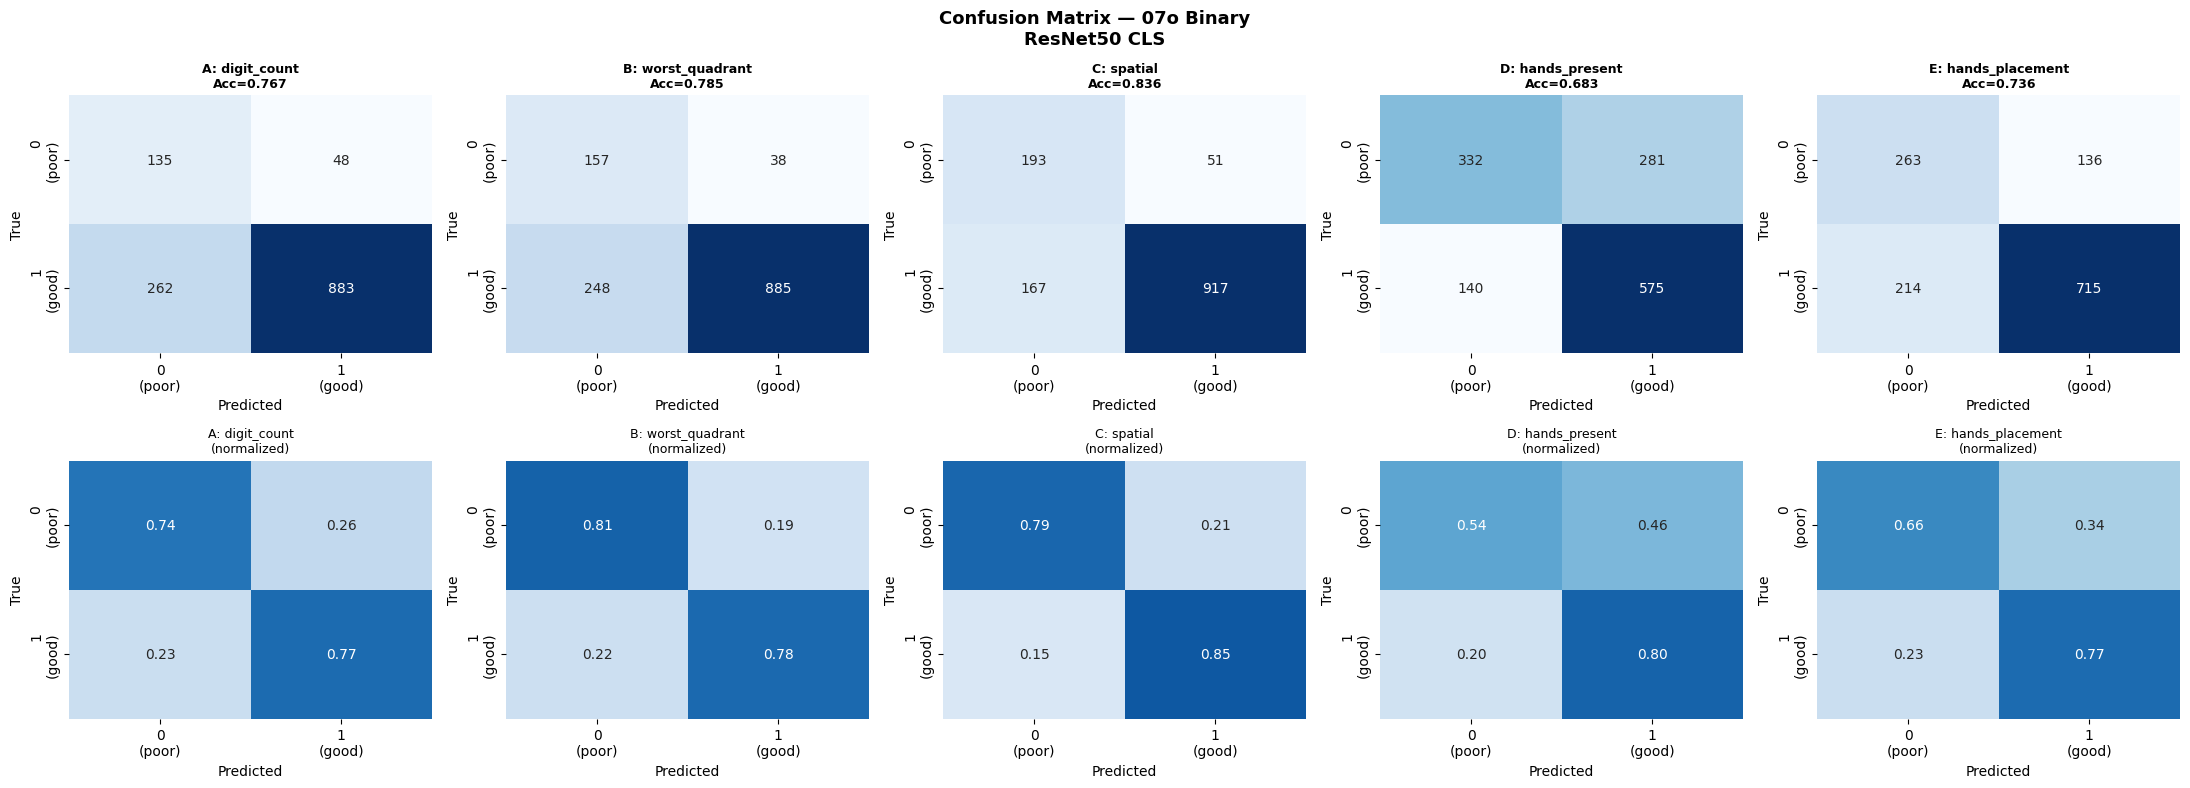

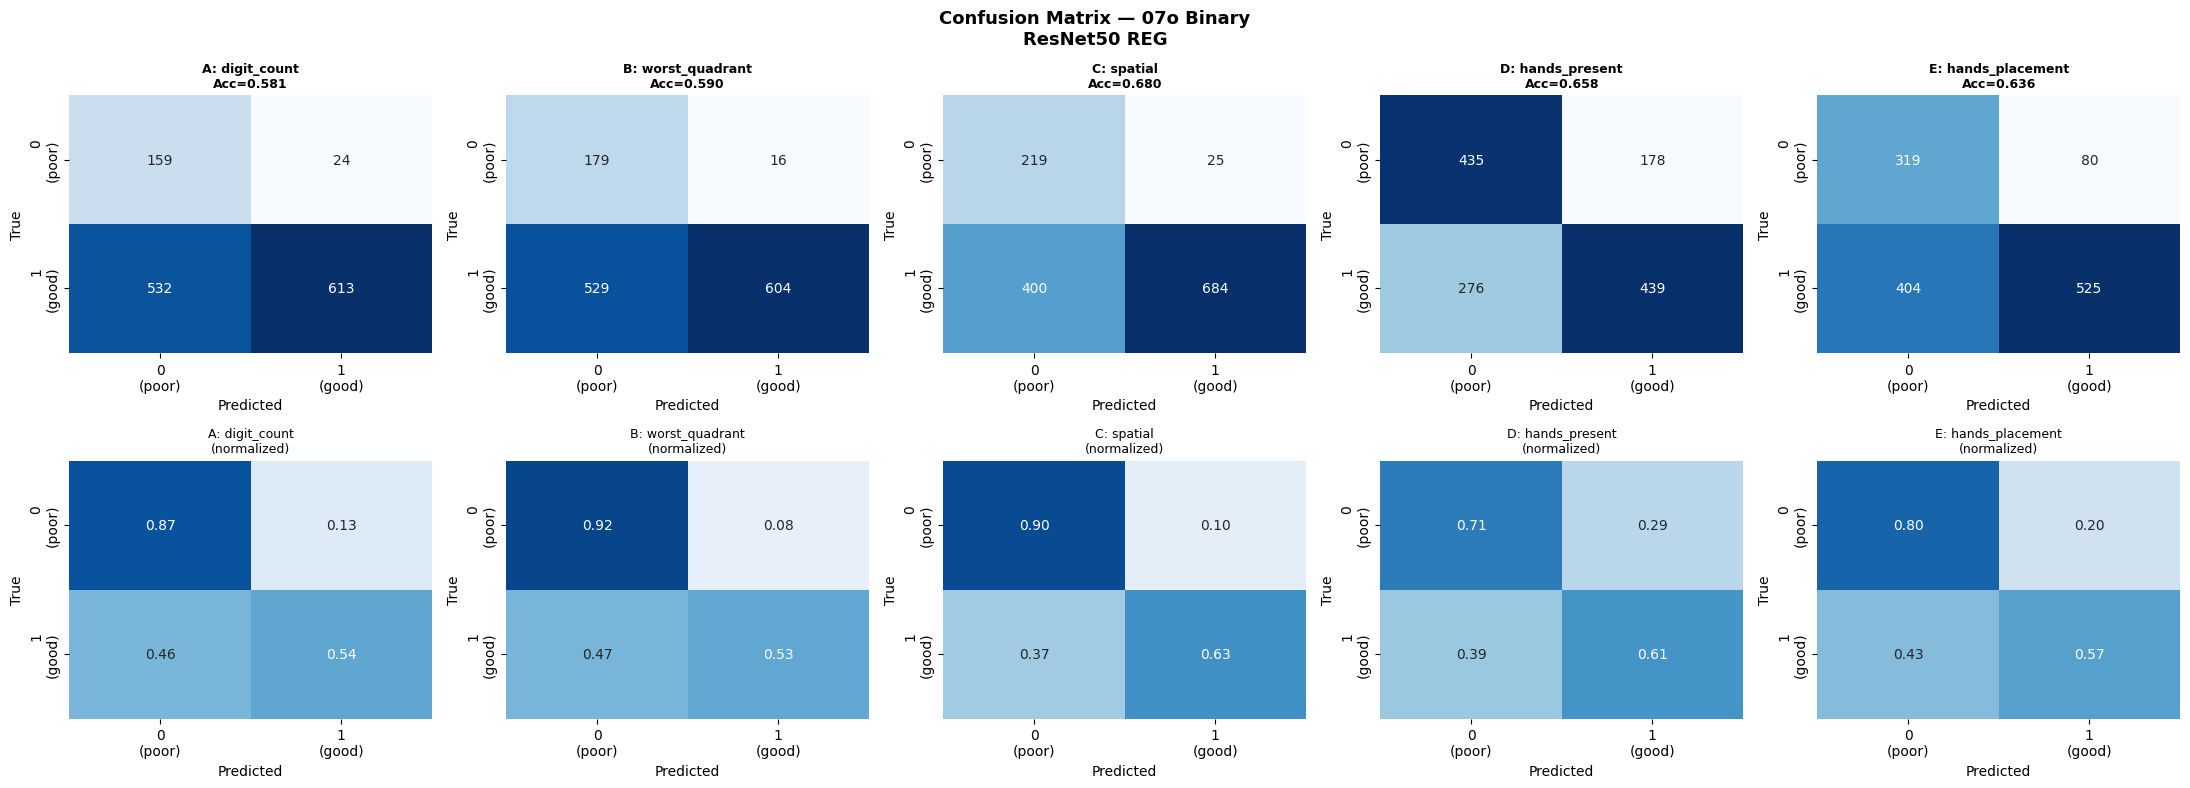

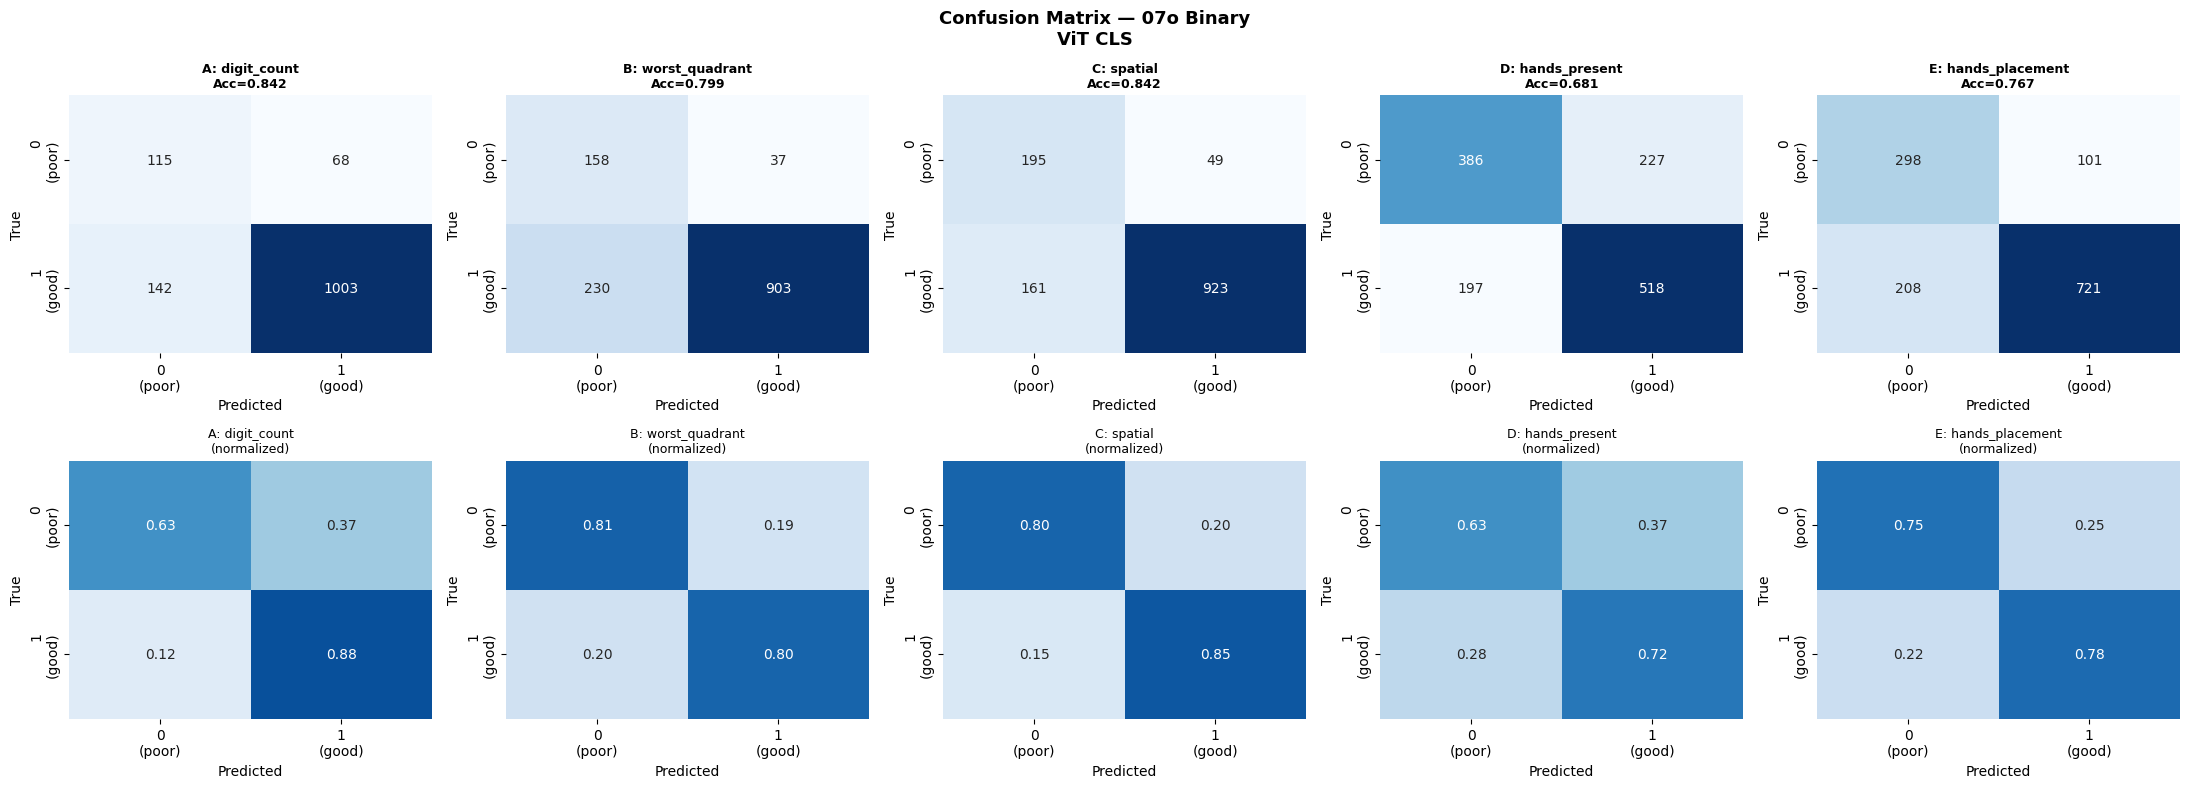

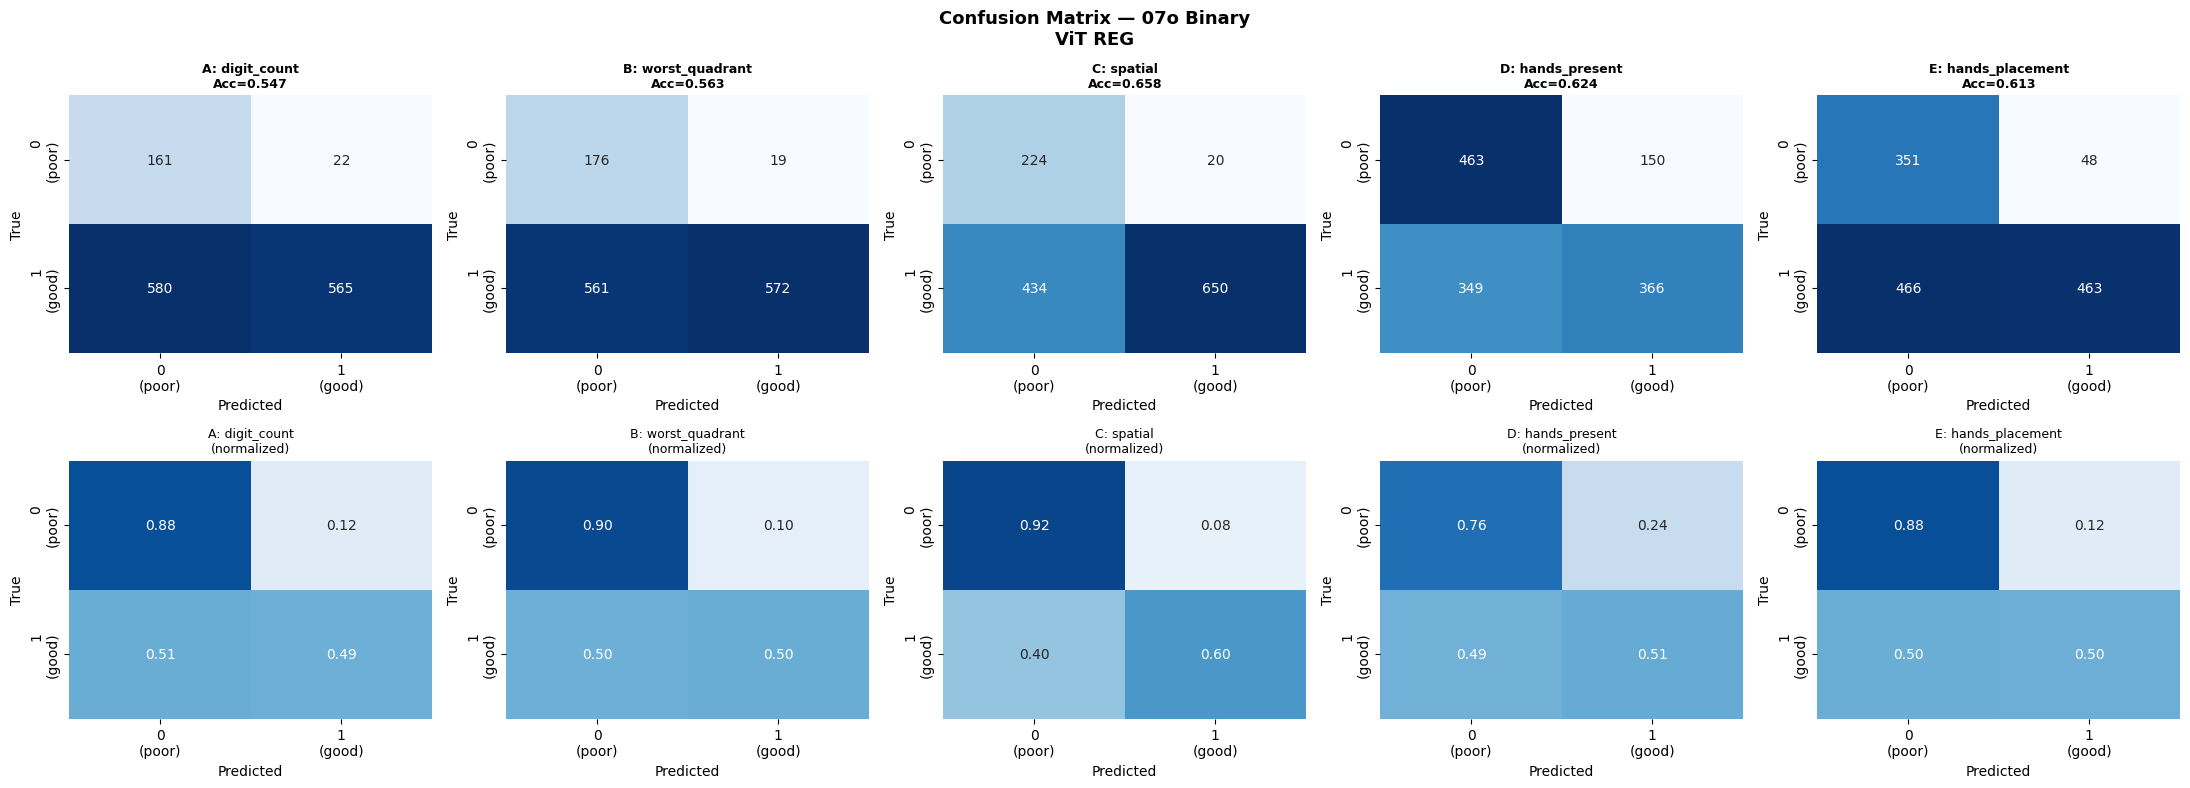

In [ ]:
domain_names_bin = {
    0: 'A: digit_count',
    1: 'B: worst_quadrant',
    2: 'C: spatial',
    3: 'D: hands_present',
    4: 'E: hands_placement',
}
short_names = {
    'resnet50_cls': 'ResNet50 CLS',
    'resnet50_reg': 'ResNet50 REG',
    'vit_cls'     : 'ViT CLS',
    'vit_reg'     : 'ViT REG',
}

for m_key, data in all_binary_data.items():
    preds  = data['preds']
    labels = data['labels']

    fig, axes = plt.subplots(2, 5, figsize=(22, 8))

    for d_idx, d_name in domain_names_bin.items():
        true_d = labels[:, d_idx].astype(int)
        pred_d = preds[:, d_idx].astype(int)

        cm      = confusion_matrix(
            true_d, pred_d, labels=[0,1]
        )
        cm_norm = cm.astype(float)
        row_sum = cm.sum(axis=1, keepdims=True)
        row_sum[row_sum == 0] = 1
        cm_norm = cm_norm / row_sum

        ax_raw  = axes[0][d_idx]
        ax_norm = axes[1][d_idx]

        sns.heatmap(
            cm, annot=True, fmt='d',
            cmap='Blues', ax=ax_raw,
            xticklabels=['0\n(poor)','1\n(good)'],
            yticklabels=['0\n(poor)','1\n(good)'],
            cbar=False
        )
        acc = (true_d == pred_d).mean()
        ax_raw.set_title(
            f'{d_name}\nAcc={acc:.3f}',
            fontsize=9, fontweight='bold'
        )
        ax_raw.set_xlabel('Predicted')
        ax_raw.set_ylabel('True')

        sns.heatmap(
            cm_norm, annot=True, fmt='.2f',
            cmap='Blues', ax=ax_norm,
            xticklabels=['0\n(poor)','1\n(good)'],
            yticklabels=['0\n(poor)','1\n(good)'],
            cbar=False, vmin=0, vmax=1
        )
        ax_norm.set_title(
            f'{d_name}\n(normalized)',
            fontsize=9
        )
        ax_norm.set_xlabel('Predicted')
        ax_norm.set_ylabel('True')

    plt.suptitle(
        f'Confusion Matrix — 07o Binary\n'
        f'{short_names[m_key]}',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(
        f'{RESULT_FOLDER}/07o_{m_key}_confusion.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()

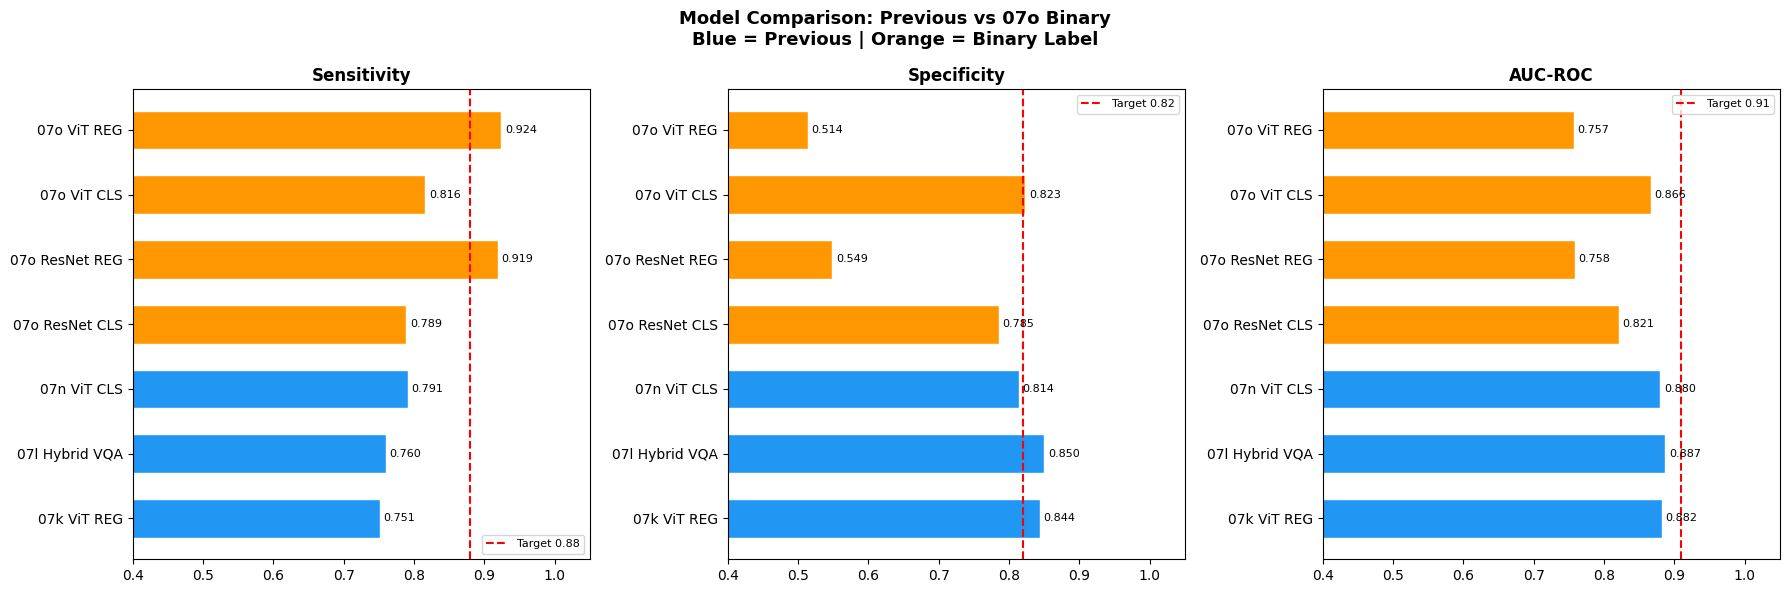

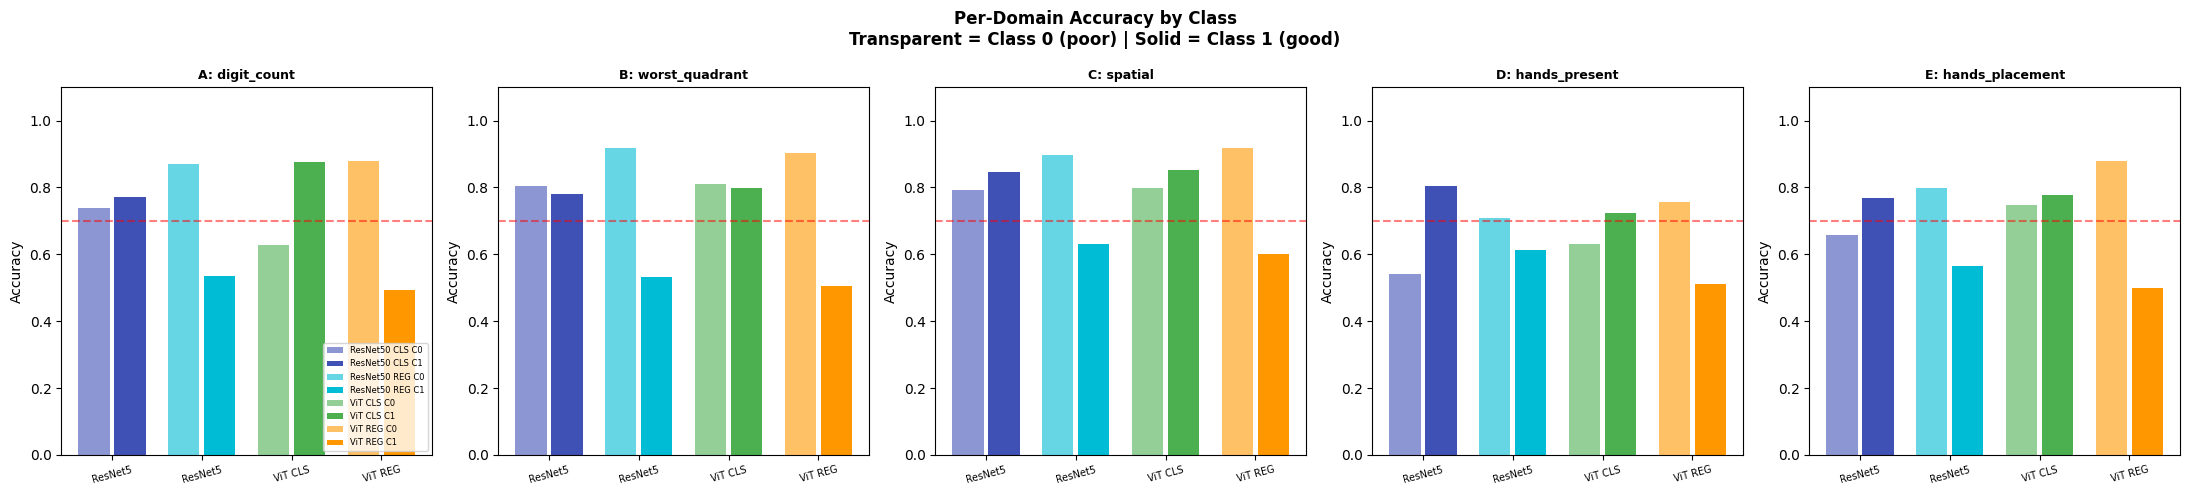

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

all_results = {
    '07k ViT REG'   : {'sens':0.751,'spec':0.844,'auc':0.882},
    '07l Hybrid VQA': {'sens':0.760,'spec':0.850,'auc':0.887},
    '07n ViT CLS'   : {'sens':0.791,'spec':0.814,'auc':0.880},
    '07o ResNet CLS': {'sens':0.789,'spec':0.785,'auc':0.821},
    '07o ResNet REG': {'sens':0.919,'spec':0.549,'auc':0.758},
    '07o ViT CLS'   : {'sens':0.816,'spec':0.823,'auc':0.866},
    '07o ViT REG'   : {'sens':0.924,'spec':0.514,'auc':0.757},
}

names  = list(all_results.keys())
colors = [
    '#2196F3' if '07k' in n or '07l' in n
    or '07n' in n else '#FF9800'
    for n in names
]

for ax_idx, (metric, title, target) in enumerate([
    ('sens', 'Sensitivity', 0.88),
    ('spec', 'Specificity', 0.82),
    ('auc',  'AUC-ROC',     0.91),
]):
    vals = [all_results[n][metric] for n in names]
    bars = axes[ax_idx].barh(
        names, vals,
        color=colors, edgecolor='white',
        height=0.6
    )
    axes[ax_idx].axvline(
        x=target, color='red',
        linestyle='--', linewidth=1.5,
        label=f'Target {target}'
    )
    axes[ax_idx].set_title(title, fontsize=12,
                            fontweight='bold')
    axes[ax_idx].set_xlim(0.4, 1.05)
    axes[ax_idx].legend(fontsize=8)

    for bar, val in zip(bars, vals):
        axes[ax_idx].text(
            val + 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center', fontsize=8
        )

plt.suptitle(
    'Model Comparison: Previous vs 07o Binary\n'
    'Blue = Previous | Orange = Binary Label',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    f'{RESULT_FOLDER}/07o_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
domain_list = ['A', 'B', 'C', 'D', 'E']
domain_full = {
    'A': 'A: digit_count',
    'B': 'B: worst_quadrant',
    'C': 'C: spatial',
    'D': 'D: hands_present',
    'E': 'E: hands_placement',
}

m_keys  = list(all_binary_data.keys())
x       = np.arange(len(m_keys))
colors2 = ['#3F51B5','#00BCD4','#4CAF50','#FF9800']

for d_idx, d in enumerate(domain_list):
    ax = axes[d_idx]

    for m_idx, m_key in enumerate(m_keys):
        preds  = all_binary_data[m_key]['preds']
        labels = all_binary_data[m_key]['labels']
        true_d = labels[:, d_idx].astype(int)
        pred_d = preds[:, d_idx].astype(int)
        acc    = (true_d == pred_d).mean()

        mask0 = (true_d == 0)
        mask1 = (true_d == 1)
        acc0  = (pred_d[mask0] == 0).mean() \
                if mask0.sum() > 0 else 0
        acc1  = (pred_d[mask1] == 1).mean() \
                if mask1.sum() > 0 else 0

        ax.bar(
            m_idx - 0.2, acc0, 0.35,
            color=colors2[m_idx],
            alpha=0.6, label=f'{short_names[m_key]} C0'
            if d_idx == 0 else ''
        )
        ax.bar(
            m_idx + 0.2, acc1, 0.35,
            color=colors2[m_idx],
            alpha=1.0, label=f'{short_names[m_key]} C1'
            if d_idx == 0 else ''
        )

    ax.set_title(domain_full[d], fontsize=9,
                 fontweight='bold')
    ax.set_xticks(range(len(m_keys)))
    ax.set_xticklabels(
        [s[:7] for s in short_names.values()],
        fontsize=7, rotation=15
    )
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.1)
    ax.axhline(y=0.7, color='red',
               linestyle='--', alpha=0.5)

    if d_idx == 0:
        ax.legend(fontsize=6, loc='lower right')

plt.suptitle(
    'Per-Domain Accuracy by Class\n'
    'Transparent = Class 0 (poor) | '
    'Solid = Class 1 (good)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    f'{RESULT_FOLDER}/07o_domain_accuracy.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

In [ ]:
from scipy.stats import gaussian_kde
import numpy as np

all_binary_raw = {}

for backbone, mode in [
    ('resnet50', 'cls'),
    ('resnet50', 'reg'),
    ('vit',      'cls'),
    ('vit',      'reg'),
]:
    model_name = f'binary_{backbone}_{mode}'
    path       = f'{MODEL_FOLDER}/{model_name}_best.pth'

    model = CDTBinaryModel(
        backbone_name=backbone
    ).to(device)
    model.load_state_dict(
        torch.load(path, map_location=device)
    )
    model.eval()

    raw_list    = []
    labels_list = []

    with torch.no_grad():
        for images, labels in test_loader:
            images  = images.to(device)
            outputs = model(images, mode=mode)

            if mode == 'reg':
                raw = torch.stack(
                    [o.squeeze(-1) for o in outputs],
                    dim=1
                )
            else:
                raw = torch.stack(
                    [torch.softmax(o, dim=1)[:, 1]
                     for o in outputs],
                    dim=1
                )

            raw_list.append(raw.cpu())
            labels_list.append(labels.cpu())

    all_binary_raw[f'{backbone}_{mode}'] = {
        'raw'   : torch.cat(raw_list).numpy(),
        'labels': torch.cat(labels_list).numpy(),
    }

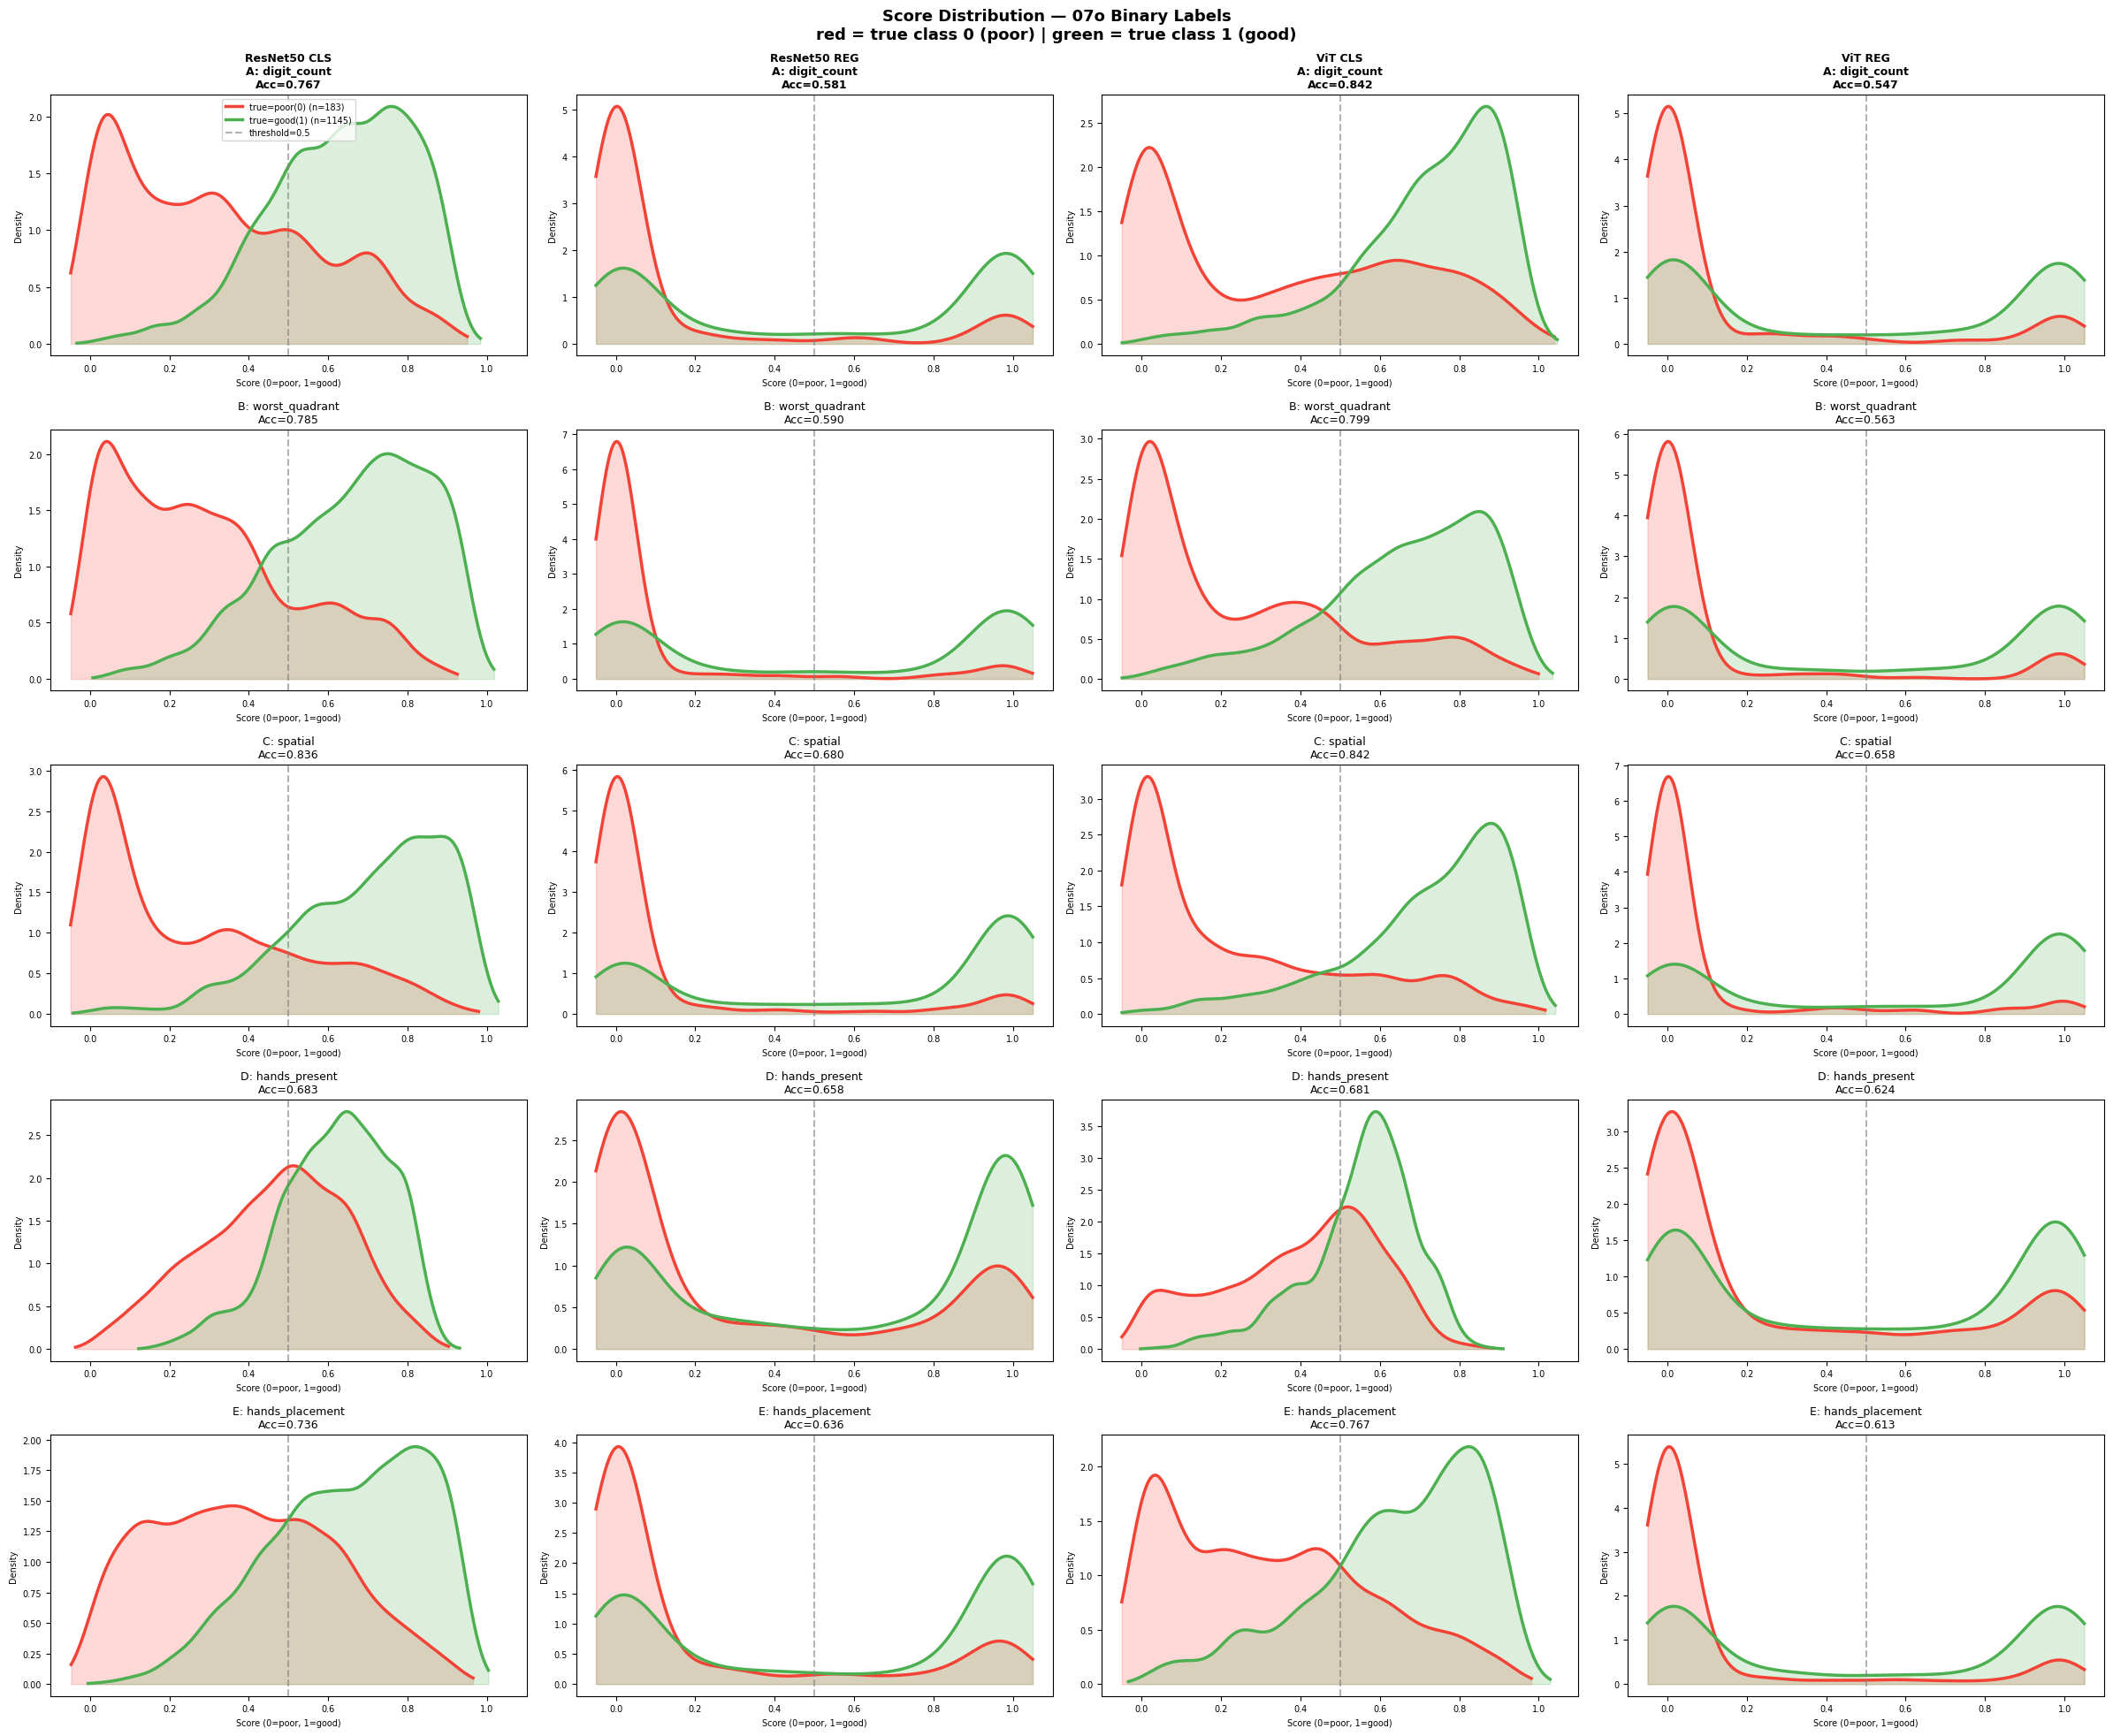

In [ ]:
domain_names_bin = {
    0: 'A: digit_count',
    1: 'B: worst_quadrant',
    2: 'C: spatial',
    3: 'D: hands_present',
    4: 'E: hands_placement',
}

colors_bin = {
    0: '#F44336',
    1: '#4CAF50',
}

model_keys  = list(all_binary_raw.keys())
short_names = {
    'resnet50_cls': 'ResNet50 CLS',
    'resnet50_reg': 'ResNet50 REG',
    'vit_cls'     : 'ViT CLS',
    'vit_reg'     : 'ViT REG',
}

fig, axes = plt.subplots(
    5, 4, figsize=(24, 20)
)

for d_idx, d_name in domain_names_bin.items():
    for m_idx, m_key in enumerate(model_keys):
        ax      = axes[d_idx][m_idx]
        raw     = all_binary_raw[m_key]['raw']
        labels  = all_binary_raw[m_key]['labels']
        true_d  = labels[:, d_idx].astype(int)
        score_d = raw[:, d_idx]

        plotted = False
        for true_val in [0, 1]:
            mask   = (true_d == true_val)
            scores = score_d[mask]
            n      = mask.sum()
            if n < 2:
                continue

            try:
                kde    = gaussian_kde(
                    scores, bw_method=0.2
                )
                x_min  = max(-0.1, scores.min()-0.05)
                x_max  = min(1.1,  scores.max()+0.05)
                x_vals = np.linspace(x_min, x_max, 300)
                y_vals = kde(x_vals)

                label_name = (
                    f'true={"poor(0)" if true_val==0 else "good(1)"} '
                    f'(n={n})'
                )
                ax.plot(
                    x_vals, y_vals,
                    color=colors_bin[true_val],
                    linewidth=2.5,
                    label=label_name
                )
                ax.fill_between(
                    x_vals, y_vals,
                    color=colors_bin[true_val],
                    alpha=0.2
                )
                plotted = True
            except Exception as e:
                pass

        ax.axvline(
            x=0.5, color='gray',
            linestyle='--', alpha=0.6,
            linewidth=1.5,
            label='threshold=0.5'
        )

        preds  = all_binary_raw[m_key]['labels']
        true_d_full = labels[:, d_idx].astype(int)
        pred_d = (score_d > 0.5).astype(int)
        acc    = (pred_d == true_d_full).mean()

        if d_idx == 0:
            ax.set_title(
                f'{short_names[m_key]}\n'
                f'{d_name}\nAcc={acc:.3f}',
                fontsize=9, fontweight='bold'
            )
        else:
            ax.set_title(
                f'{d_name}\nAcc={acc:.3f}',
                fontsize=9
            )

        ax.set_xlabel('Score (0=poor, 1=good)',
                      fontsize=7)
        ax.set_ylabel('Density', fontsize=7)
        ax.set_xlim(-0.1, 1.1)
        ax.tick_params(labelsize=7)

        if d_idx == 0 and m_idx == 0:
            ax.legend(fontsize=7, loc='upper center')

        if not plotted:
            ax.text(0.5, 0.5, 'No data',
                    ha='center', va='center',
                    transform=ax.transAxes)

plt.suptitle(
    'Score Distribution — 07o Binary Labels\n'
    'red = true class 0 (poor) | '
    'green = true class 1 (good)\n',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    f'{RESULT_FOLDER}/07o_distribution.png',
    dpi=150, bbox_inches='tight'
)
plt.show()